# 03 · Dataset sanity check

Verify PeanutDataset and the DataLoader on real data: shapes, dtypes, class
values, and that train returns 512×512 crops while val returns full 960×720
frames. Visual confirmation that a batch is well formed before training.

In [1]:
from pathlib import Path

import torch
from torch.utils.data import DataLoader

from cropweed_seg.dataset import PeanutDataset
from cropweed_seg.transforms import build_transforms

ROOT = Path.cwd().parent

train_ds = PeanutDataset(ROOT, "train", build_transforms("train"))
val_ds = PeanutDataset(ROOT, "val", build_transforms("val"))

print(f"train: {len(train_ds)} samples")
print(f"val:   {len(val_ds)} samples")

# One sample, before batching
img, mask = train_ds[0]
print(f"\nsingle train sample:")
print(f"  image: {tuple(img.shape)} {img.dtype}")
print(f"  mask:  {tuple(mask.shape)} {mask.dtype}  classes {torch.unique(mask).tolist()}")

train: 280 samples
val:   60 samples

single train sample:
  image: (3, 512, 512) torch.float32
  mask:  (512, 512) torch.uint8  classes [0, 1, 2]


In [2]:
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)

img_batch, mask_batch = next(iter(train_loader))
print("train batch:")
print(f"  images: {tuple(img_batch.shape)} {img_batch.dtype}")
print(f"  masks:  {tuple(mask_batch.shape)} {mask_batch.dtype}")
print(f"  mask classes in batch: {torch.unique(mask_batch).tolist()}")

val_img_batch, val_mask_batch = next(iter(val_loader))
print("\nval batch:")
print(f"  images: {tuple(val_img_batch.shape)} {val_img_batch.dtype}")
print(f"  masks:  {tuple(val_mask_batch.shape)} {val_mask_batch.dtype}")

train batch:
  images: (8, 3, 512, 512) torch.float32
  masks:  (8, 512, 512) torch.uint8
  mask classes in batch: [0, 1, 2]

val batch:
  images: (4, 3, 720, 960) torch.float32
  masks:  (4, 720, 960) torch.uint8


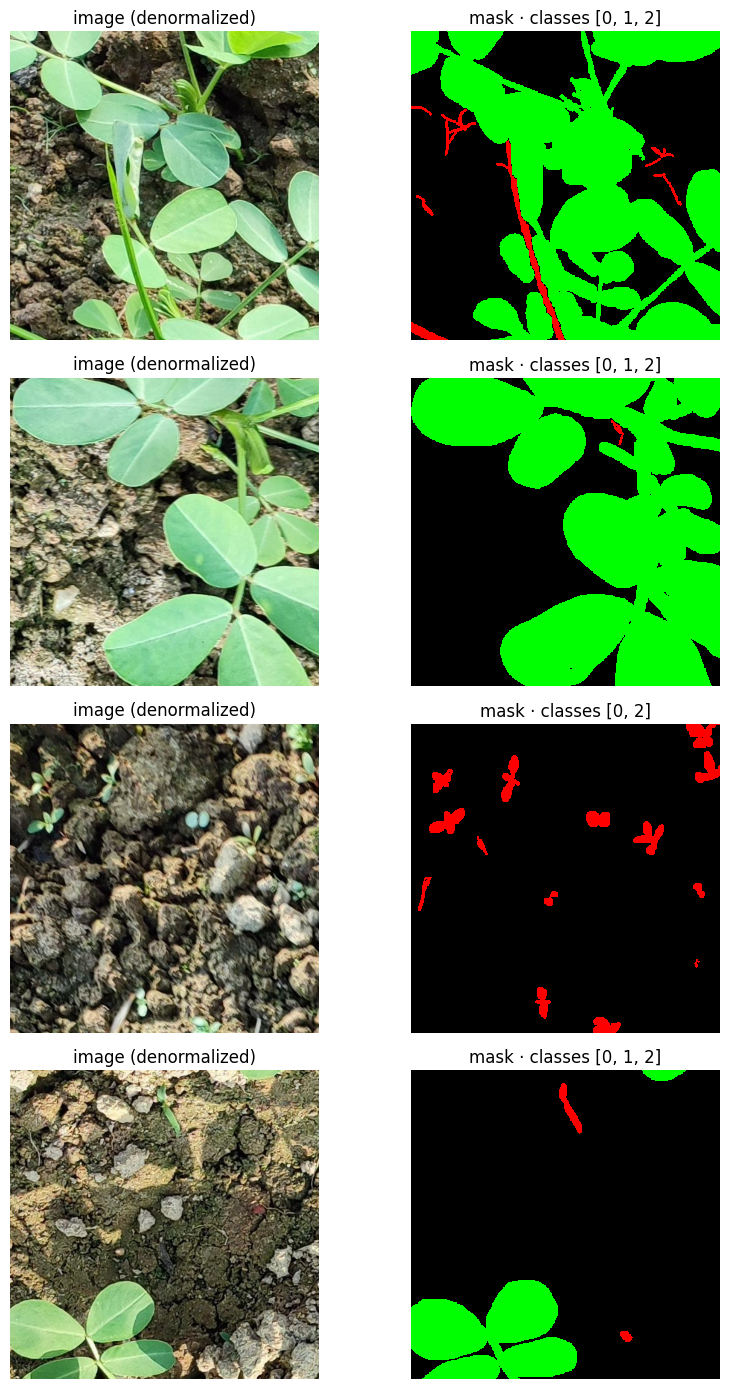

In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from cropweed_seg.transforms import IMAGENET_MEAN, IMAGENET_STD

INDEX_CMAP = ListedColormap(["black", "lime", "red"])
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def denormalize(img: torch.Tensor) -> torch.Tensor:
    """Undo ImageNet normalization for display, back to [0, 1]."""
    return (img * std + mean).clamp(0, 1)

fig, axes = plt.subplots(4, 2, figsize=(9, 14))
for row, (img, mask) in zip(axes, zip(img_batch, mask_batch)):
    row[0].imshow(denormalize(img).permute(1, 2, 0))
    row[0].set_title("image (denormalized)")
    row[1].imshow(mask, cmap=INDEX_CMAP, vmin=0, vmax=2, interpolation="nearest")
    row[1].set_title(f"mask · classes {torch.unique(mask).tolist()}")
    for ax in row:
        ax.axis("off")
plt.tight_layout()
plt.show()